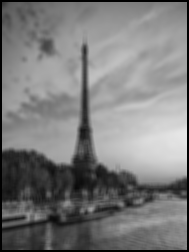

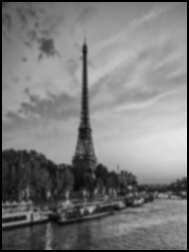

In [2]:
import numpy as np
import cv2
from PIL import Image
from google.colab.patches import cv2_imshow

rick = Image.open('/content/sample_data/paris_cool.jpg')
matoriginal = np.array(rick)

# Convertir a escala de grises
filas, cols =(matoriginal.shape[0], matoriginal.shape[1])
escgris = np.zeros((matoriginal.shape[0], matoriginal.shape[1]))
for i in range(filas):
    for j in range(cols):
        escgris[i,j] = int(0.07 * matoriginal[i,j,0] + 0.72 *matoriginal[i,j,1] + 0.21 * matoriginal[i,j,2])



media = np.ones((5, 5), dtype=float) / 25
gauss = np.array([[1, 4, 7, 4, 1], [4, 16, 26, 16, 4],[7, 26, 41, 26, 7], [4, 16, 26, 16, 4], [1, 4, 7, 4, 1]], dtype=float) / 273


newmedia = np.zeros_like(escgris)
newgauss = np.zeros_like(escgris)


#media
for i in range(2, escgris.shape[0]-2):
    for j in range(2, escgris.shape[1]-2):
        suma1=0
        for k in range(-2, 3):
            for l in range(-2, 3):
                suma1 +=escgris[i+k, j+l] *media[k+2, l+2]
        newmedia[i, j]=suma1


#suavizado gaussiano
for i in range(2, escgris.shape[0] -2):
    for j in range(2, escgris.shape[1]-2):
        suma2=0
        for k in range(-2, 3):
            for l in range(-2, 3):
                suma2 +=escgris[i+k, j+l] * gauss[k+2, l+2]
        newgauss[i,j] =suma2



# Muestra las imágenes
rick.show()
cv2_imshow(newmedia)
cv2_imshow(newgauss)